## Module Overview

In previous modules, students explored datasets, cleaned data, validated assumptions, and began looking for patterns. This module introduces the next major analytical skill:

> **Reasoning under uncertainty.**

Real-world data is noisy. Analysts rarely have access to an entire population. Instead, they usually work with a sample and use that sample to make a careful claim about a larger group.

This module focuses on the foundational ideas behind statistical inference:

- Sampling variability
- The Central Limit Theorem
- Confidence intervals
- Basic hypothesis testing


---

## Learning Objectives

By the end of this module, students will be able to:

- Explain the difference between a **sample** and a **population**
- Describe why different samples from the same population can produce different results
- Use simulation to demonstrate **sampling variability**
- Explain the Central Limit Theorem at a conceptual level
- Build and interpret a confidence interval
- Explain the purpose of a hypothesis test
- Run a simple hypothesis test in Python
- Communicate statistical uncertainty in plain language

---

## Big Idea

Exploratory data analysis helps us describe what we see in a dataset.

Statistical inference helps us answer a deeper question:

> **How confident are we that what we see in our sample reflects something true about the larger population?**

This module helps students move from:

> “The sample average is 52.”

to:

> “Based on this sample, we estimate that the true population average is likely between 49 and 55.”

That shift is the foundation of statistical reasoning.

---

## Key Vocabulary

| Term | Meaning |
|---|---|
| Population | The full group we want to understand |
| Sample | The subset of the population we actually observe |
| Parameter | A true value about the population |
| Statistic | A value calculated from a sample |
| Inference | Using sample data to make a careful claim about the population |

---

## Example

If a company has 100,000 customers but surveys 500 of them:

- The **100,000 customers** are the population
- The **500 surveyed customers** are the sample
- The true average satisfaction score for all customers is a population parameter
- The average satisfaction score from the 500 surveyed customers is a sample statistic

The sample statistic is useful, but it is not guaranteed to equal the true population parameter.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# from matplotlib import pyplot as plt
from scipy import stats

In [2]:
# set our np seed, helps with reproducibility
np.random.seed(42)

In [3]:
# Creating a simulated population
population_size = 100_000

purchase_amounts = np.random.gamma(
    shape=2.0,
    scale=25.0,
    size=population_size
)

In [4]:
population = pd.DataFrame({
    "purchase_amount": purchase_amounts
})

population.head()

,purchase_amount
0,59.841985
1,37.361618
2,34.557090
3,34.557557
4,116.242860


In [5]:
population["purchase_amount"].describe()

count    100000.000000
mean         50.085210
std          35.393559
min           0.104087
25%          24.069749
50%          42.086928
75%          67.348702
max         377.642579
Name: purchase_amount, dtype: float64

In [7]:
true_pop_mean = population["purchase_amount"].mean()
true_pop_std = population["purchase_amount"].std()

true_pop_mean, true_pop_std

(50.08520986651151, 35.3935588835632)

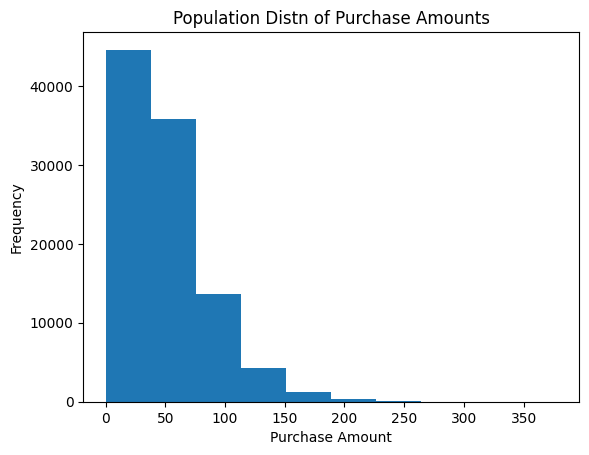

In [9]:
plt.hist(population["purchase_amount"])
plt.title("Population Distn of Purchase Amounts")
plt.xlabel("Purchase Amount")
plt.ylabel("Frequency");

---

Sampling variability

In [14]:
sample_1 = population.sample(n=100, random_state=1)

In [15]:
sample_2 = population.sample(n=100, random_state=2)

In [16]:
sample_3 = population.sample(n=100, random_state=3)

In [17]:
sample_1_mean = sample_1["purchase_amount"].mean()
sample_2_mean = sample_2["purchase_amount"].mean()
sample_3_mean = sample_3["purchase_amount"].mean()

sample_1_mean, sample_2_mean, sample_3_mean

(52.54763089123581, 55.5988486074322, 46.67443151175268)

In [18]:
sample_size = 100
num_samples = 1000

sample_means = []

for i in range(num_samples):
    sample = population["purchase_amount"].sample(n=sample_size, replace=True)
    sample_mean = sample.mean()
    sample_means.append(sample_mean)

sample_means = np.array(sample_means)

sample_means[:10]

array([46.88053879, 50.99657536, 48.61481506, 48.46157089, 52.85058274,
       46.95692056, 44.87675859, 46.15722164, 45.29914806, 47.23733678])

In [19]:
sample_means.mean(), sample_means.std()

(50.15828538353223, 3.4879766565517176)

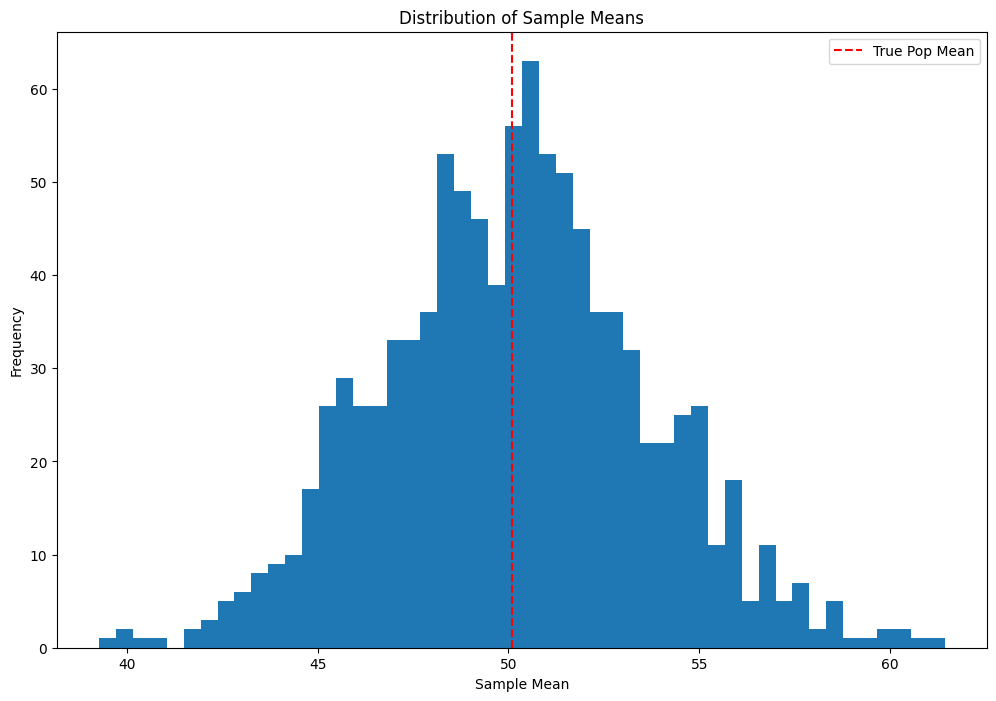

In [22]:
plt.figure(figsize=(12, 8))
plt.hist(sample_means, bins=50)
plt.axvline(true_pop_mean, linestyle="--", label = "True Pop Mean", color="red")
plt.title("Distribution of Sample Means")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")
plt.legend()

---

Comparing different sampling sizes

In [33]:
def get_sample_means(data, sample_size, num_samples=1000):
    means = []

    for i in range(num_samples):
        sample = data.sample(n=sample_size, replace=True)
        means.append(sample.mean())

    return np.array(means)

In [34]:
means_n_10 = get_sample_means(population["purchase_amount"], sample_size=10)
means_n_30 = get_sample_means(population["purchase_amount"], sample_size=30)
means_n_100 = get_sample_means(population["purchase_amount"], sample_size=100)
means_n_500 = get_sample_means(population["purchase_amount"], sample_size=500)

Text(0, 0.5, 'Frequency')

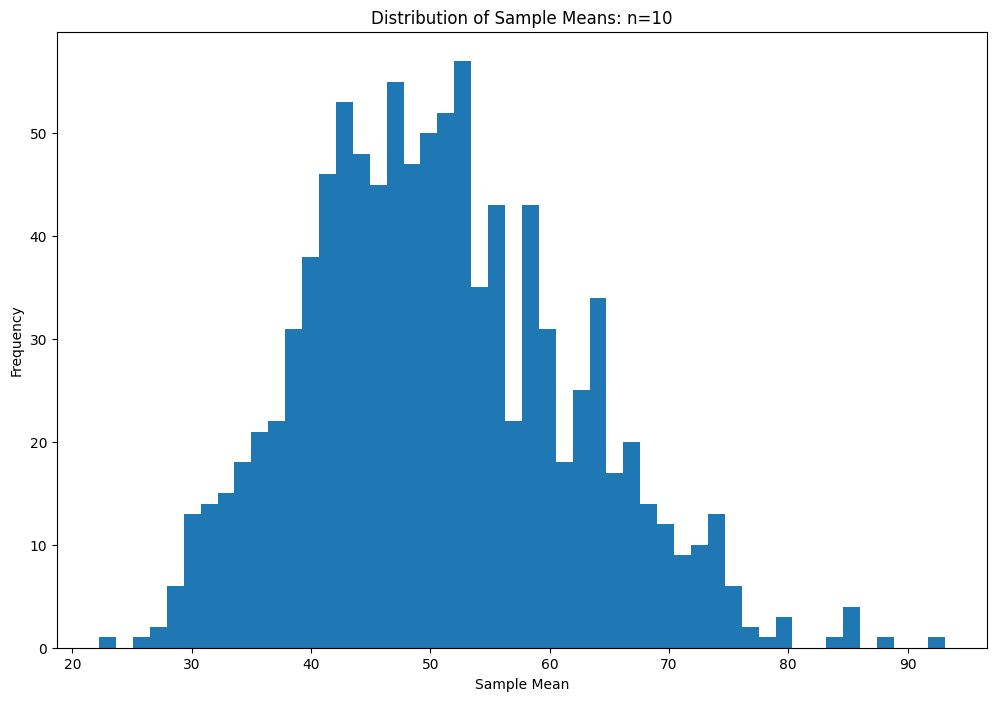

In [26]:
plt.figure(figsize=(12, 8))
plt.hist(means_n_10, bins=50)
plt.title("Distribution of Sample Means: n=10")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")

Text(0, 0.5, 'Frequency')

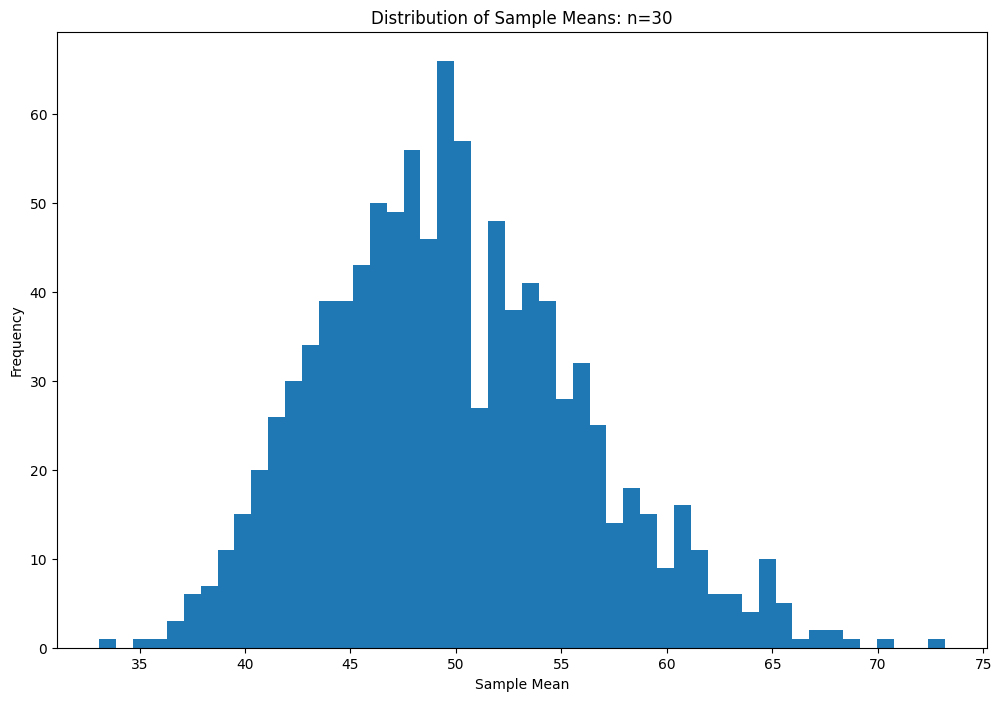

In [27]:
plt.figure(figsize=(12, 8))
plt.hist(means_n_30, bins=50)
plt.title("Distribution of Sample Means: n=30")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")

Text(0, 0.5, 'Frequency')

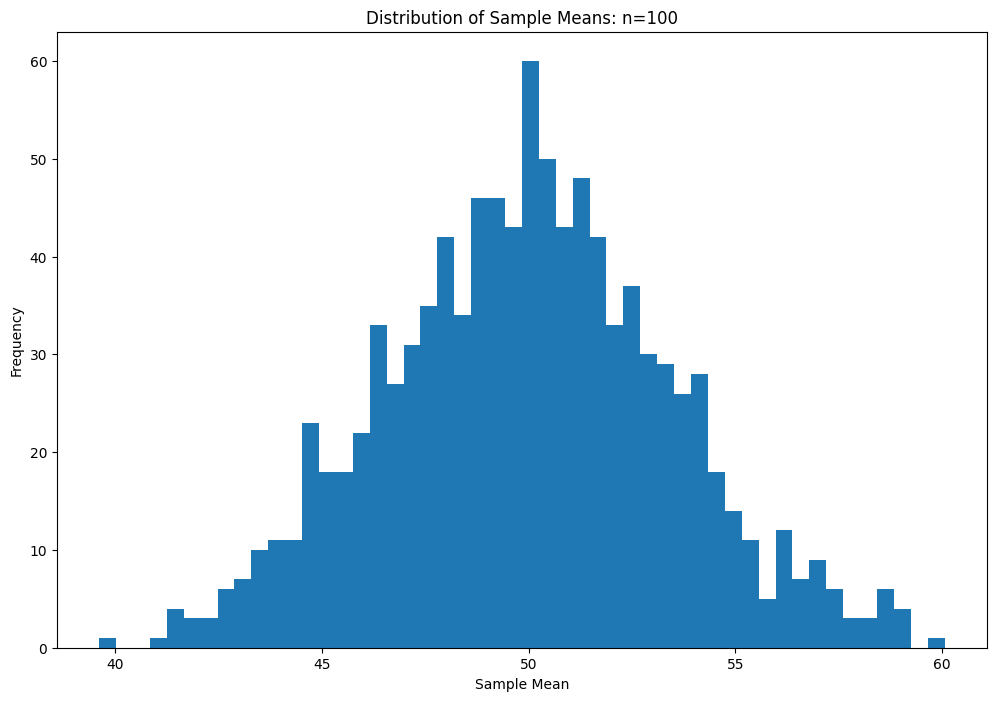

In [28]:
plt.figure(figsize=(12, 8))
plt.hist(means_n_100, bins=50)
plt.title("Distribution of Sample Means: n=100")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")

Text(0, 0.5, 'Frequency')

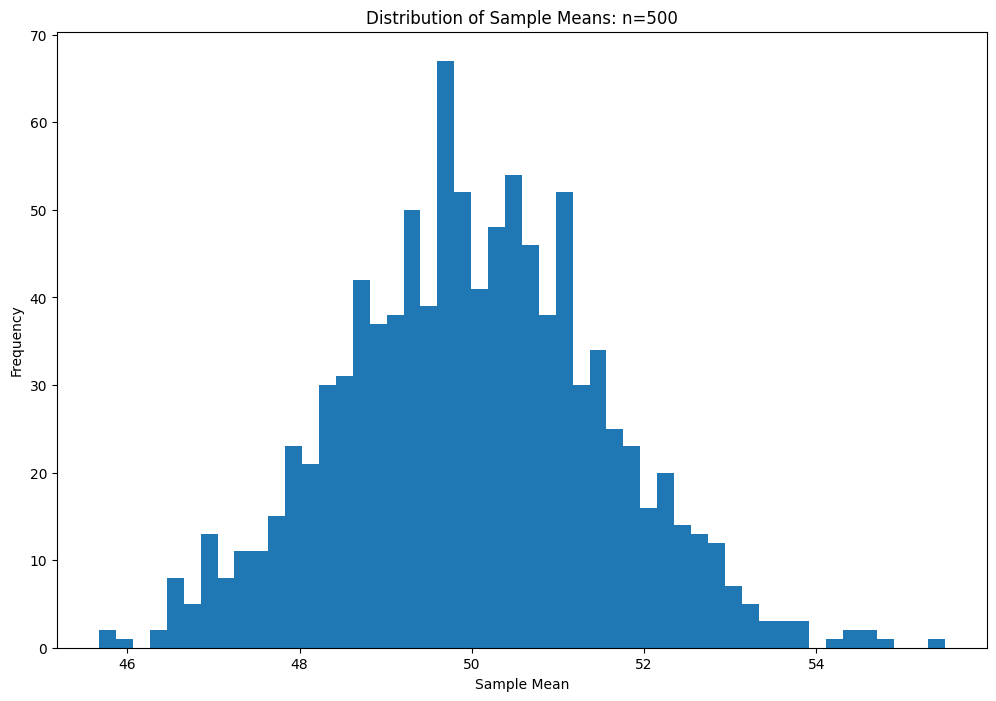

In [29]:
plt.figure(figsize=(12, 8))
plt.hist(means_n_500, bins=50)
plt.title("Distribution of Sample Means: n=500")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")

In [35]:
# Calculate and compare our sample errors

summary = pd.DataFrame({
    "sample_size": [10, 30, 100, 500],
    "mean_of_sample_means": [
        means_n_10.mean(),
        means_n_30.mean(),
        means_n_100.mean(),
        means_n_500.mean(),
    ],
    "standard_error":[
        means_n_10.std(),
        means_n_30.std(),
        means_n_100.std(),
        means_n_500.std(),
    ]
})

summary

,sample_size,mean_of_sample_means,standard_error
0,10,50.698327,11.141870
1,30,49.810178,6.189437
2,100,50.230930,3.636672
3,500,50.104546,1.565526


---

## Confidence Intervals

In [40]:
sample = population["purchase_amount"].sample(n=500, random_state = 11)

# calculate the mean and stdev
sample_mean = sample.mean()
sample_std = sample.std()

# num of obs
n = len(sample)

# set our confidence level and our alpha
confidence_level = 0.95
alpha = 1 - confidence_level

# calculate our critical value
t_critical = stats.t.ppf(1 - alpha / 2, df=n-1)

# calc our std error
standard_error = sample_std / np.sqrt(n)

# margin of error
margin_of_error = t_critical * standard_error

# calculate the upper and lower bounds of our confidence interval
ci_lower = sample_mean - margin_of_error
ci_upper = sample_mean + margin_of_error

sample_mean, ci_lower, ci_upper

(53.18928663471201, 49.907461103215866, 56.47111216620816)

In [41]:
print(f"Sample mean: ${sample_mean}")
print(f"95% confidence interval: (${ci_lower}, ${ci_upper}")
print(f"True population mean: ${true_pop_mean}")

Sample mean: $53.18928663471201
95% confidence interval: ($49.907461103215866, $56.47111216620816
True population mean: $50.08520986651151


---

Quick Hypothesis Test

Null Hypothesis (H0): Average purchase price is $50

Alternative Hypothesis (HA): Average Purchase ≠ $50

In [42]:
sample = population["purchase_amount"].sample(n=100, random_state=25)

hypothesized_mean = 50

In [43]:
t_statistic, p_value = stats.ttest_1samp(
    a = sample,
    popmean=hypothesized_mean
)

t_statistic, p_value

(0.34242141446028634, 0.7327596932675124)

In [44]:
alpha = 0.05

if p_value < alpha:
    print("Reject the Null Hypothesis")
    print("The sample provides evidence that the true mean is difference from $50")
else:
    print("Fail to reject the Null Hypothesis")
    print("The sample does not provide strong evidence that the true mean is different from $50")

Fail to reject the Null Hypothesis
The sample does not provide strong evidence that the true mean is different from $50
